Movimiento Geométrico Browniano

$$d(\ln S_t) = \left(\mu - \frac{1}{2}\sigma^2\right) dt + \sigma dW_t$$

\begin{equation*}
S_t = S_0 \exp ((\mu-\frac{\sigma^2}{2})t+\sigma W_t)
\end{equation*}

donde $W_t$ es un proceso de Wiener o movimiento browniano, $\mu$ es el _drift_ porcentual y $\sigma$ es la volatilidad porcentual. 

Para discretizar y adaptar, trabajamos con los log-retornos $x_t = \ln(S_t / S_{t-1})$. Por el Lema de Itô, sabemos que:$$x_t \sim \mathcal{N}\left( (\mu - \frac{1}{2}\sigma^2)\Delta t, \sigma^2 \Delta t \right)$$

C:\Users\migue\AppData\Local\Temp\ipykernel_19768\241792995.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(data_full.loc[split_idx]) # Precio inicial de la simulación
C:\Users\migue\AppData\Local\Temp\ipykernel_19768\241792995.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  drift_geo = float(train_rets.mean() * 252)
C:\Users\migue\AppData\Local\Temp\ipykernel_19768\241792995.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sigma_est = float(train_rets.std() * np.sqrt(252))


Parámetros Calibrados (2022):
Mu (Anual): 0.1178
Sigma (Anual): 0.1285


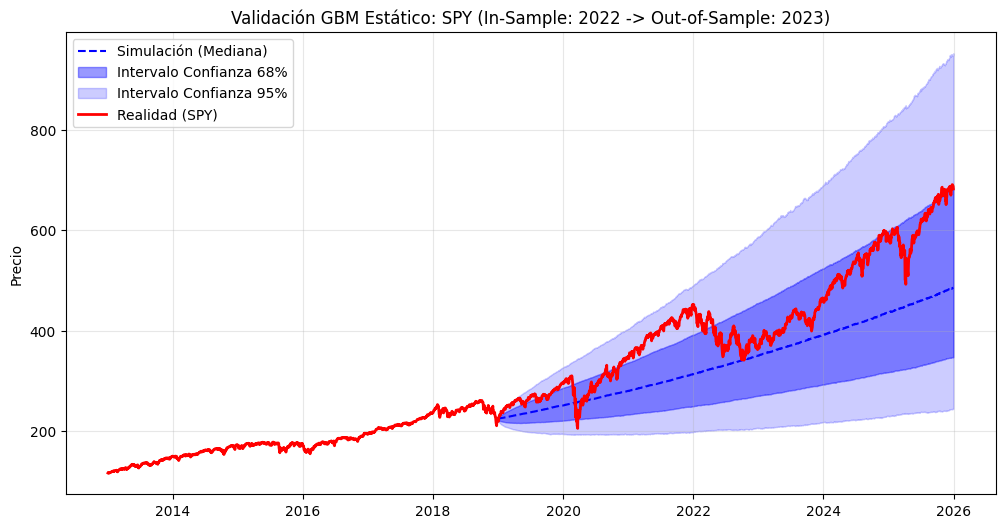

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. Higiene de Datos ---
def get_data(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    # Trabajamos con precios de Cierre Ajustado para incluir dividendos
    prices = data['Adj Close']
    # Log-retornos son aditivos, esenciales para GBM
    log_returns = np.log(prices / prices.shift(1)).dropna()
    return prices, log_returns

# --- 2. Calibración (In-Sample) ---
# Usamos el último año para entrenar
ticker = 'SPY'
start_date = '2013-01-01'
split_date = '2019-01-01' # Fin del entrenamiento
end_date = '2026-01-01'   # Fin de la validación

data_full, log_ret_full = get_data(ticker, start_date, end_date)

# Separar Train (In-Sample) y Test (Out-of-Sample)
# Usar asof() para encontrar la fecha más cercana disponible
split_idx = data_full.index.asof(pd.Timestamp(split_date))
train_rets = log_ret_full.loc[:split_idx]
S0 = float(data_full.loc[split_idx]) # Precio inicial de la simulación
actual_prices = data_full.loc[split_idx:] # La realidad para comparar

# Estimadores MLE para GBM constante
# Anualizamos (252 días de trading)
drift_geo = float(train_rets.mean() * 252)
sigma_est = float(train_rets.std() * np.sqrt(252))

# Corrección de Itô para el Drift geométrico
mu_est = drift_geo + 0.5 * sigma_est**2

print(f"Parámetros Calibrados (2022):\nMu (Anual): {mu_est:.4f}\nSigma (Anual): {sigma_est:.4f}")

# --- 3. Motor de Monte Carlo (Vectorizado) ---
T_days = len(actual_prices) # Horizonte de proyección
dt = 1/252
N_SIMS = 10000 # 10,000 universos paralelos

# Generar matriz de ruidos aleatorios [días, simulaciones]
# np.random.normal es el motor estocástico dZ
Z = np.random.normal(0, 1, (T_days, N_SIMS))

# Construcción de caminos (Path generation)
# S_t = S_0 * exp(cumsum(drift + diffusion))
daily_drift = drift_geo * dt
daily_diffusion = sigma_est * np.sqrt(dt) * Z

# Suma acumulada de exponentes
exponents = np.cumsum(daily_drift + daily_diffusion, axis=0)
# Añadimos fila de ceros al inicio para t=0
exponents = np.vstack([np.zeros((1, N_SIMS)), exponents])

# Caminos de precios
S_paths = S0 * np.exp(exponents)
# Recortamos el último para ajustar dimensiones si es necesario
S_paths = S_paths[:len(actual_prices)]

# --- 4. Visualización y Validación ---
plt.figure(figsize=(12, 6))

# Graficar intervalo de confianza (Quantiles)
# El "Río" de probabilidad
q05 = np.percentile(S_paths, 2.275, axis=1)
q15 = np.percentile(S_paths, 15.865, axis=1)
q50 = np.percentile(S_paths, 50, axis=1) # Mediana
q85 = np.percentile(S_paths, 84.135, axis=1)
q95 = np.percentile(S_paths, 97.725, axis=1)

plt.plot(actual_prices.index, q50, color='blue', label='Simulación (Mediana)', linestyle='--')

plt.fill_between(actual_prices.index, q15, q85, color='blue', alpha=0.4, label='Intervalo Confianza 68%')
plt.fill_between(actual_prices.index, q05, q95, color='blue', alpha=0.2, label='Intervalo Confianza 95%')

# La Realidad
plt.plot(data_full.index, data_full, color='red', linewidth=2, label=f'Realidad ({ticker})')

plt.title(f'Validación GBM Estático: {ticker} (In-Sample: 2022 -> Out-of-Sample: 2023)')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

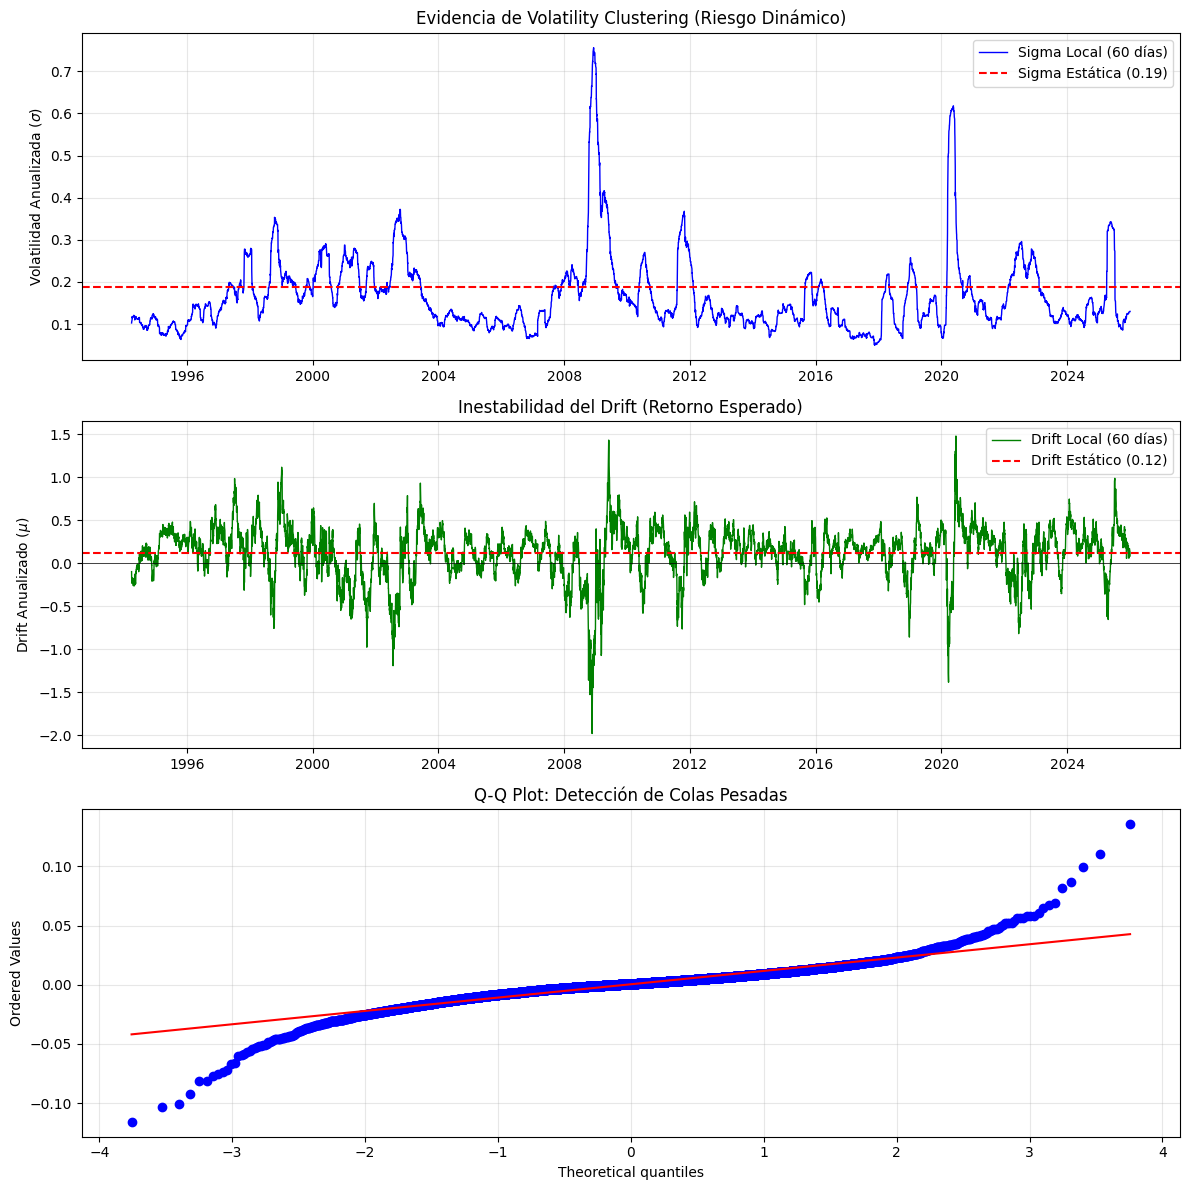

--- Diagnóstico del Paciente (SPY) ---
Curtosis (Exceso): 11.17 (Normal = 0.0)
Sesgo (Skewness):  -0.25 (Normal = 0.0)
VEREDICTO: Distribución Leptocúrtica. El modelo Gaussiano subestima el riesgo extremo.


In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# --- 1. Obtención de Datos ---
ticker = 'SPY'
data = yf.download(ticker, start='1994-01-01', end='2026-01-01', progress=False, auto_adjust=False)
log_returns = np.log(data['Adj Close'] / data['Adj Close'].shift(1)).dropna()

# --- 2. Análisis de Ventana Móvil (Rolling Analysis) ---
window = 60 # Ventana de 3 meses (aprox)

# Calculamos mu y sigma locales (anualizados)
rolling_geo_drift = log_returns.rolling(window).mean() * 252
rolling_sigma = log_returns.rolling(window).std() * np.sqrt(252)
# Corrección de Itô para el Drift geométrico local
rolling_drift = rolling_geo_drift + 0.5 * rolling_sigma**2

# Parámetros Estáticos (Benchmark) para todo el periodo
static_sigma = (log_returns.std() * np.sqrt(252)).item()
static_drift = (log_returns.mean() * 252 + 0.5 * static_sigma**2).item()


# --- 3. Visualización de la No-Estacionariedad ---
fig, ax = plt.subplots(3, 1, figsize=(12, 12))

# Panel 1: El mito de la Sigma constante
ax[0].plot(rolling_sigma.index, rolling_sigma, label=f'Sigma Local ({window} días)', color='blue', linewidth=1)
ax[0].axhline(static_sigma, color='red', linestyle='--', label=f'Sigma Estática ({static_sigma:.2f})')
ax[0].set_title('Evidencia de Volatility Clustering (Riesgo Dinámico)')
ax[0].set_ylabel(r'Volatilidad Anualizada $(\sigma)$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Panel 2: El mito del Drift constante
ax[1].plot(rolling_drift.index, rolling_drift, label=f'Drift Local ({window} días)', color='green', linewidth=1)
ax[1].axhline(static_drift, color='red', linestyle='--', label=f'Drift Estático ({static_drift:.2f})')
ax[1].axhline(0, color='black', linewidth=0.5)
ax[1].set_title('Inestabilidad del Drift (Retorno Esperado)')
ax[1].set_ylabel(r'Drift Anualizado $(\mu)$')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Panel 3: QQ-Plot (Test de Normalidad)
# Si los puntos azules se desvían de la línea roja en los extremos, hay "Colas Pesadas"
stats.probplot(log_returns.squeeze(), dist="norm", plot=ax[2])
ax[2].set_title('Q-Q Plot: Detección de Colas Pesadas')
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. Métricas de "Falsabilidad" ---
kurtosis = stats.kurtosis(log_returns).item()
skewness = stats.skew(log_returns).item()

print(f"--- Diagnóstico del Paciente ({ticker}) ---")
print(f"Curtosis (Exceso): {kurtosis:.2f} (Normal = 0.0)")
print(f"Sesgo (Skewness):  {skewness:.2f} (Normal = 0.0)")
if kurtosis > 1.0:
    print("VEREDICTO: Distribución Leptocúrtica. El modelo Gaussiano subestima el riesgo extremo.")
else:
    print("VEREDICTO: Distribución cercana a la Normal.")

Data check - Drift: min=-0.653106, max=0.987481, std=0.237003
Data check - Sigma: min=0.086087, max=0.342173, std=0.073239

PEARSON CORRELATION: Rolling Drift vs Rolling Volatility
Correlation Coefficient (r): -0.391520
P-value: 1.2128e-17
Sample Size (n): 442

Interpretation: Moderate negative correlation
Statistical Significance: Statistically significant (p < 0.05)


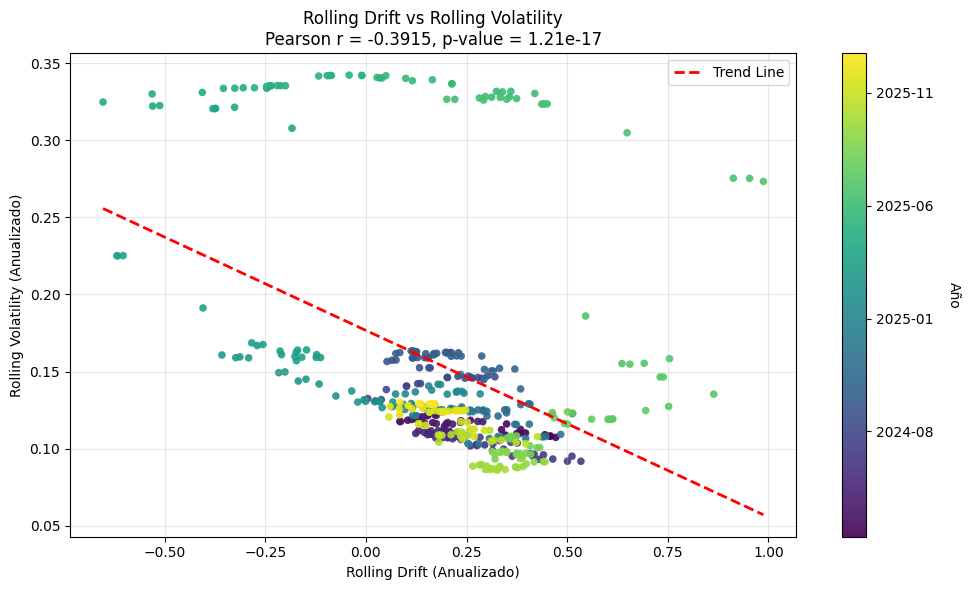

In [30]:
from scipy.stats import pearsonr
import numpy as np

# Remove NaN values for correlation calculation
valid_mask = rolling_drift.notna() & rolling_sigma.notna()
drift_clean = rolling_drift[valid_mask].values.flatten()
sigma_clean = rolling_sigma[valid_mask].values.flatten()

# Remove any remaining NaN or inf values
valid_idx = np.isfinite(drift_clean) & np.isfinite(sigma_clean)
drift_clean = drift_clean[valid_idx]
sigma_clean = sigma_clean[valid_idx]

print(f"Data check - Drift: min={drift_clean.min():.6f}, max={drift_clean.max():.6f}, std={drift_clean.std():.6f}")
print(f"Data check - Sigma: min={sigma_clean.min():.6f}, max={sigma_clean.max():.6f}, std={sigma_clean.std():.6f}")
print()

# Calculate Pearson correlation coefficient
pearson_corr, p_value = pearsonr(drift_clean, sigma_clean)

# Ensure scalar values
pearson_corr = float(np.real(pearson_corr))
p_value = float(np.real(p_value))

print("=" * 60)
print(f"PEARSON CORRELATION: Rolling Drift vs Rolling Volatility")
print("=" * 60)
print(f"Correlation Coefficient (r): {pearson_corr:.6f}")
print(f"P-value: {p_value:.4e}")
print(f"Sample Size (n): {len(drift_clean)}")
print()

# Interpretation
if abs(pearson_corr) < 0.3:
    strength = "Weak"
elif abs(pearson_corr) < 0.7:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "Positive" if pearson_corr > 0 else "Negative"
significance = "Statistically significant (p < 0.05)" if p_value < 0.05 else "Not statistically significant (p >= 0.05)"

print(f"Interpretation: {strength} {direction.lower()} correlation")
print(f"Statistical Significance: {significance}")
print("=" * 60)

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Get the dates corresponding to valid data points
dates_series = rolling_drift[valid_mask]
dates_array = dates_series.index.values
dates_valid = dates_array[valid_idx]

# Convert dates to fractional years for coloring
import matplotlib.dates as mdates
time_numeric = mdates.date2num(dates_valid)

# Create scatter plot with color gradient based on actual time
scatter = ax.scatter(drift_clean, sigma_clean, c=time_numeric, cmap='viridis', 
                     alpha=0.9, s=30, edgecolors='none')

# Add colorbar with date formatting
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año', rotation=270, labelpad=20)
# Format colorbar ticks as dates
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
cbar.ax.yaxis.set_major_locator(ticker.MaxNLocator(6))

# Add trend line using polyfit with higher degree and error handling
try:
    if drift_clean.std() > 0 and sigma_clean.std() > 0:
        z = np.polyfit(drift_clean, sigma_clean, 1)
        p_poly = np.poly1d(z)
        x_trend = np.linspace(drift_clean.min(), drift_clean.max(), 100)
        ax.plot(x_trend, p_poly(x_trend), color='red', linestyle='--', linewidth=2, label='Trend Line')
except:
    pass

ax.set_xlabel('Rolling Drift (Anualizado)')
ax.set_ylabel('Rolling Volatility (Anualizado)')
ax.set_title(f'Rolling Drift vs Rolling Volatility\nPearson r = {pearson_corr:.4f}, p-value = {p_value:.2e}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()